In [1]:
from IPython.display import display, Markdown
from PIL import Image
import os
import base64
import io

In [2]:
def print_markdown(text):
    """Display a markdown version of the given text"""
    display(Markdown(text))

def encode_image_to_binary(image_to_encode: str|Image.Image):
    if isinstance(image_to_encode, str):
        if not os.path.exists(image_to_encode):
            raise FileNotFoundError(f"Missing file: {image_to_encode}")
        with open(image_to_encode, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")

    elif isinstance(image_to_encode, Image.Image):
        buffered_image = io.BytesIO()
        image_format = image_to_encode.format or "JPEG"
        image_to_encode.save(buffered_image, format=image_format)
        return base64.b64encode(buffered_image.getvalue()).decode("utf-8")
    else:
        raise TypeError("Image must be File Path or PIL Image Object")



In [9]:
food_image = "greek_salad.png"

image = Image.open(food_image)

print(f"General Info on {food_image} "
      f"\n---------------------------\n"
      f"Format:     {image.format}\n"
      f"Size:       {image.size}\n"
      f"Mode:       {image.mode}\n"
      f"Type:       {type(image)}\n")

General Info on greek_salad.png 
---------------------------
Format:     PNG
Size:       (1536, 1024)
Mode:       RGB
Type:       <class 'PIL.PngImagePlugin.PngImageFile'>



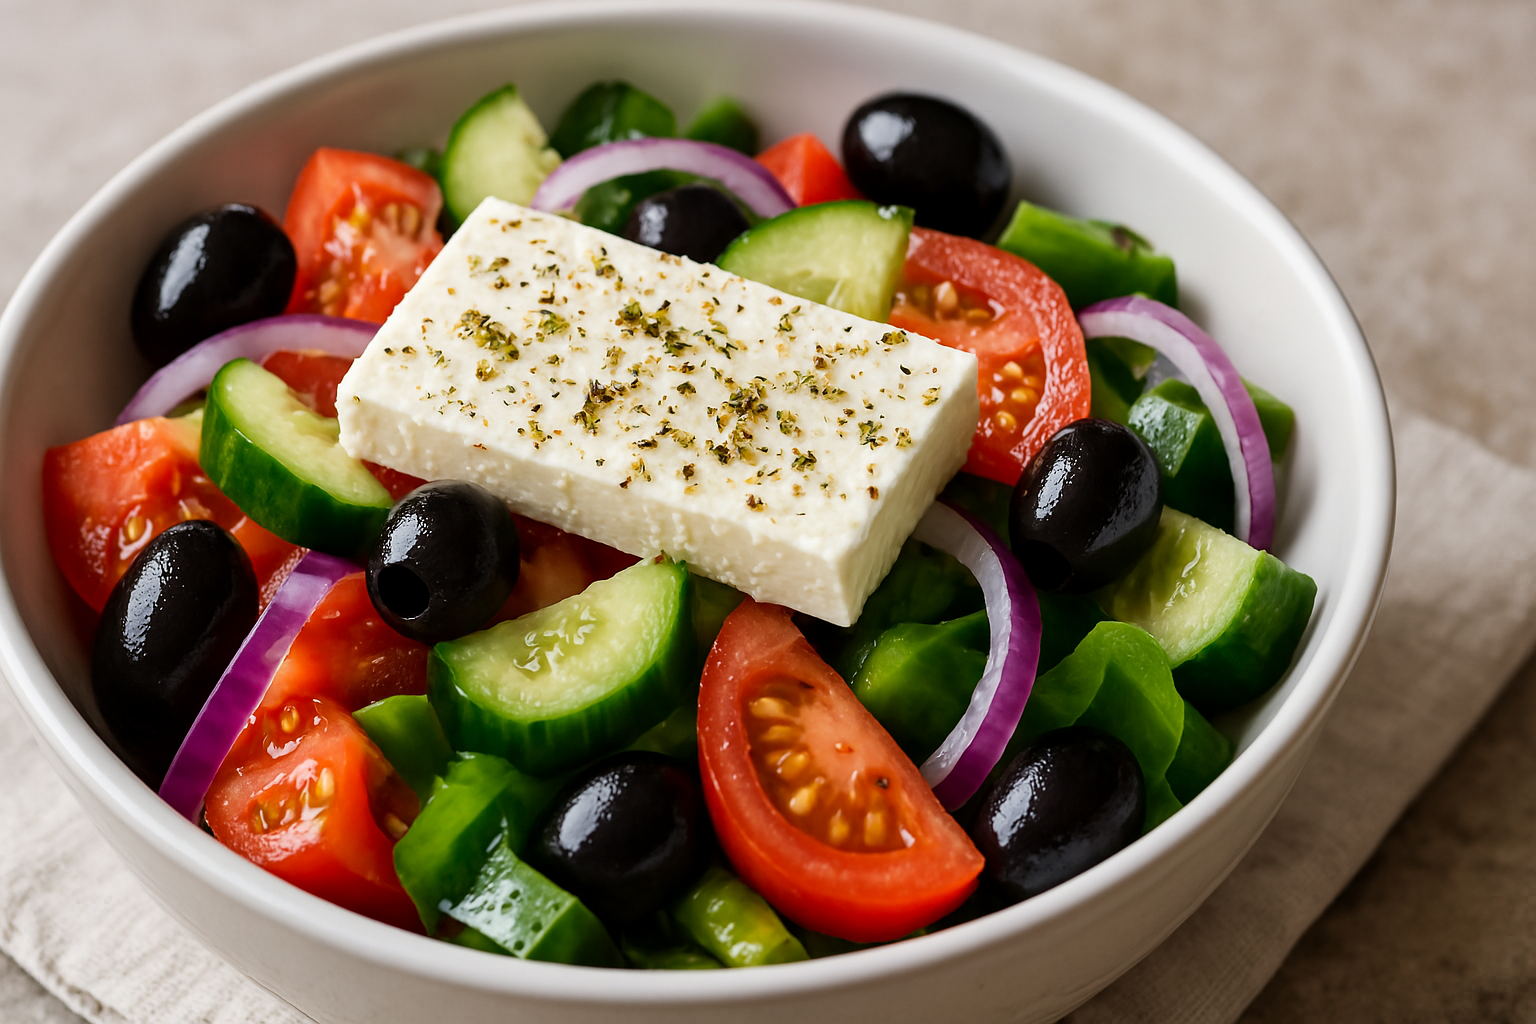

In [7]:
# Pillow library implementation to display image
image_to_analyse = image
display(image_to_analyse)

In [10]:

def query_vision_model(client, image_to_llm: Image.Image|str, prompt: str, model="gpt-4o", max_tokens=100):
    """Function to call the LLM Vision on image"""

    base64_encoded_image = encode_image_to_binary(image_to_llm)

    try:
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": prompt
                    },
                    {
                        "type": "image_url",
                        "image_url": f"data:image/png;base64,{base64_encoded_image}"
                    }
                ]
            }
        ]

        response = client.chat.completions.create(
            model=model,
            messages=messages,
            max_positions=max_tokens,
        )

        return response.choices[0].message.content
    except Exception as e:
        return f"Error: {e}"